# Notebook 6.1 — Eigenmode noise: how low-rank is it, and can it beat the wall?

*Prerequisites: notebooks 4–5, and notebook 6 (the wall).*

Notebook 6 found the reference mechanism's **wall**: at high `p` it almost never accepts a correlated noise
draw, so it falls back to independent noise. Brain patches are smooth, so the noise may not really *need* all
`p` directions — the tempting fix is to work only in the top-`k` **eigenmodes** where the noise lives. This
notebook does two things in one arc: it **measures** how low-rank the noise is (Part 1–2), then **tests
whether that can be turned into a mechanism** that beats the wall (Part 3–5). The answer to the second is a
clean *no*, for a reason worth understanding.

Runs on synthetic patches; set `USE_OASIS = True` and every experiment — including the membership tests — uses
real OASIS patches. No DP guarantees; membership advantage is a lower bound on leakage. Baseline A stays
frozen; everything here is a *separate* candidate we build and measure.

## Background — one picture

An **eigendecomposition** rotates the coordinates onto the noise cloud's own axes: each **eigenmode** `v_m` is
a direction (a spatial pattern over the patch), each **eigenvalue** `λ_m` the variance along it. Two facts make
this the right tool: correlated-over-voxels noise is **independent-over-modes** (drawing correlated noise =
drawing one independent number per mode, scaled by `√λ_m`), and because patches are smooth the cloud is long in
a few directions and flat in the rest — so **a few modes hold almost all the variance**. (Eigenmode =
principal component = SVD direction of the centered perturbations; three names for the same thing.)

The anatomy figure below shows it on one patch: the eigenvalues drop off a cliff and the running total of
variance reaches 95% after only a handful of modes.

In [11]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from scipy.stats import norm
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        sys.path.insert(0, cand); break
import privacy_harness as ph, cov_diagnostics as cd
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3})
PAL = {"mean":"#4c72b0","median":"#dd8452","variance":"#55a868"}
pipes = {"mean": ph.pipeline_mean, "median": ph.pipeline_median, "variance": ph.pipeline_variance}

USE_OASIS = True    # runs on synthetic patches by default; set True where nilearn is available and
                     # every experiment below (including the membership tests) then uses real OASIS patches.
def make_source(bs, N=40, corr=0.8, seed=0):
    if USE_OASIS:
        try: return ph.oasis_source(n=max(N,60), block_shape=bs, N=N, seed=seed)
        except Exception as e: print("OASIS unavailable ->", e)
    return ph.SyntheticBlockSource(N=N, block_shape=bs, spatial_corr=corr, base_std=1.0)

def eig_cov(M):                       # eigendecomposition of Cov(M) via SVD of centered M (N,p)
    Mc = M - M.mean(0); U, sv, Vt = np.linalg.svd(Mc, full_matrices=False)
    return np.clip((sv**2)/(M.shape[0]-1), 1e-30, None), Vt.T      # (eigenvalues desc, directions V: p x r)
def k_for(evals, frac):               # how many top modes reach a fraction of the total variance
    w = np.clip(np.sort(evals)[::-1], 0, None); return int(np.searchsorted(np.cumsum(w)/w.sum(), frac)+1)

def make_lowrank_gauss(k):            # pure GAUSSIAN noise living only in the top-k eigenmodes (no rejection)
    def mech(y, D, Sv, noise_power=None, subjects=None, **cfg):
        Dm = D.reshape(D.shape[0], -1); lam, V = eig_cov(Dm)
        kk = int(min(max(k,1), len(lam))); Vk = V[:, :kk]; sd = np.sqrt(lam[:kk])
        if noise_power is not None: sd = sd * np.sqrt(noise_power / np.sum(sd**2))
        return ph.NoiseModel(lambda rng: Vk @ (rng.standard_normal(kk)*sd),
                             cov=None, nominal_cov=(Vk*sd**2)@Vk.T)
    return mech
print("ready")

ready


[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


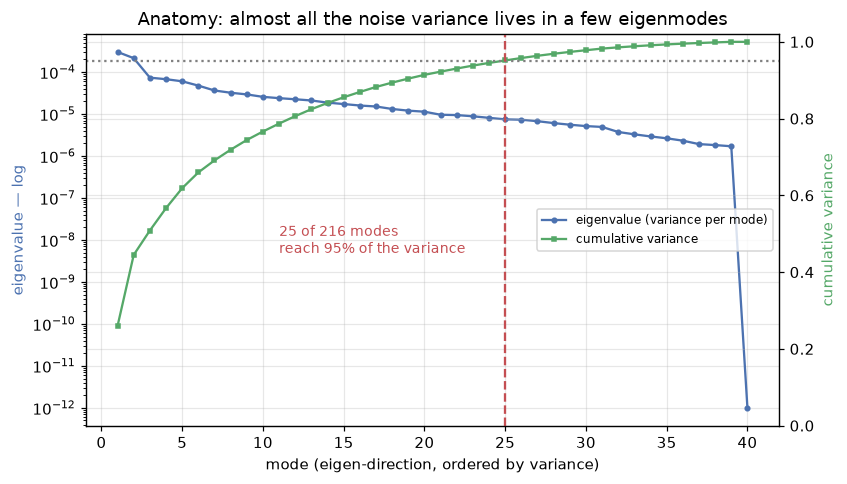

In [12]:
src = make_source((6, 6, 6), N=40)                 # p = 216, so the low-rank gap is stark
stack = src.sample(src.N, np.random.default_rng(0))
_, D, _ = ph.loo_artifacts(stack, ph.pipeline_mean)
ev, V = eig_cov(D.reshape(src.N, -1)); ev = np.sort(ev)[::-1]
cum = np.cumsum(ev) / ev.sum(); k95 = k_for(ev, 0.95)

fig, ax1 = plt.subplots(figsize=(7.8, 4.5)); ax2 = ax1.twinx()
ax1.semilogy(range(1, len(ev)+1), np.clip(ev, 1e-12, None), "o-", color="#4c72b0", ms=3, label="eigenvalue (variance per mode)")
ax2.plot(range(1, len(cum)+1), cum, "s-", color="#55a868", ms=3, label="cumulative variance")
ax2.axhline(0.95, color="grey", ls=":"); ax2.axvline(k95, color="#c44e52", ls="--")
ax2.text(k95-14, 0.45, f"{k95} of {src.p} modes\nreach 95% of the variance", color="#c44e52", fontsize=9)
ax1.set_xlabel("mode (eigen-direction, ordered by variance)")
ax1.set_ylabel("eigenvalue — log", color="#4c72b0"); ax2.set_ylabel("cumulative variance", color="#55a868")
ax2.set_ylim(0, 1.02); ax1.set_title("Anatomy: almost all the noise variance lives in a few eigenmodes")
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=8, loc="center right"); plt.tight_layout(); plt.show()


> **Two things to read correctly on that figure.** (i) The eigenvalues are *small in absolute terms* (~0.1 and
> below) because these are the perturbations of a **mean over 40 subjects** — removing one subject barely moves
> the mean (`Cov(LOO) = Cov(data)/(N−1)²`, i.e. the data covariance ÷ ~1521). The absolute scale is irrelevant;
> the mechanism rescales the noise up anyway. What matters is the *shape* — the cliff — which is scale-free.
> (ii) There are only `N−1 = 39` non-zero modes: the covariance of 40 perturbation vectors has rank at most 39,
> so the spectrum falls to ~0 at mode 40. That rank ceiling matters later.

## Part 1 — How many eigenmodes are necessary?

For each statistic and patch size, how many modes of its **LOO noise covariance** (`Cov(D)`, where `D` are the
leave-one-out perturbations) reach 90/95/99% of the total variance `Σλ_m`? The count differs *across
statistics* because each has different perturbations — the mean's are linear in the data, the median's depend
on the ordering, the variance's on squared deviations — so each has a differently-shaped noise cloud.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


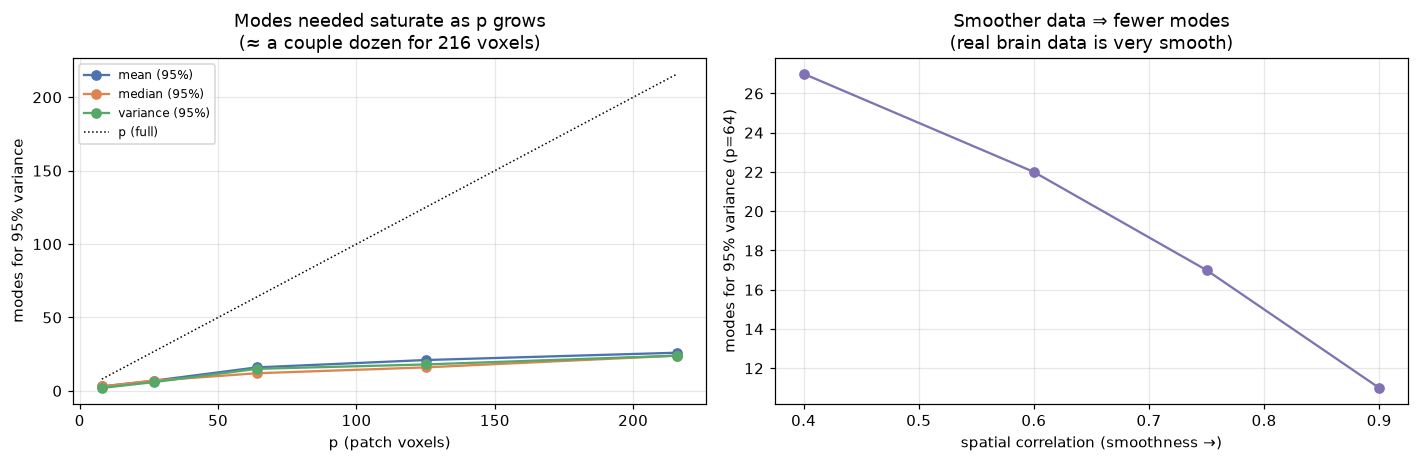

stat  mean  median  variance
p                           
8        3       3         2
27       7       7         6
64      16      12        15
125     21      16        18
216     26      24        24


In [13]:
rng = np.random.default_rng(0)
rows = []
for bs in [(2,2,2),(3,3,3),(4,4,4),(5,5,5),(6,6,6)]:
    s = make_source(bs, N=40); stack = s.sample(40, rng)
    for name, pipe in pipes.items():
        _, D, _ = ph.loo_artifacts(stack, pipe); ev, _ = eig_cov(D.reshape(40, -1))
        rows.append((s.p, name, k_for(ev, .90), k_for(ev, .95), k_for(ev, .99)))
km = pd.DataFrame(rows, columns=["p","stat","k90","k95","k99"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for name in pipes:
    g = km[km.stat == name]
    ax[0].plot(g.p, g.k95, "o-", color=PAL[name], label=f"{name} (95%)")
ax[0].plot(km.p.unique(), km.p.unique(), "k:", lw=1, label="p (full)")
ax[0].set_xlabel("p (patch voxels)"); ax[0].set_ylabel("modes for 95% variance")
ax[0].set_title("Modes needed saturate as p grows\n(≈ a couple dozen for 216 voxels)"); ax[0].legend(fontsize=8)

corrs = [0.4, 0.6, 0.75, 0.9]; s6 = None
kc = []
for c in corrs:
    s = ph.SyntheticBlockSource(N=40, block_shape=(4,4,4), spatial_corr=c); stack = s.sample(40, rng)
    _, D, _ = ph.loo_artifacts(stack, ph.pipeline_mean); ev, _ = eig_cov(D.reshape(40, -1))
    kc.append(k_for(ev, .95))
ax[1].plot(corrs, kc, "o-", color="#8172b3")
ax[1].set_xlabel("spatial correlation (smoothness →)"); ax[1].set_ylabel("modes for 95% variance (p=64)")
ax[1].set_title("Smoother data ⇒ fewer modes\n(real brain data is very smooth)")
plt.tight_layout(); plt.show()
print(km.pivot(index="p", columns="stat", values="k95").to_string())

**Read-off (Part 1).** The count **saturates** — a couple of dozen modes for 95% of the variance even at
`p=216`, while `p` keeps climbing — and the smoother the data, the fewer modes. Real brain maps are very
smooth, so they sit at the favourable, low-mode end. The noise is genuinely low-rank.

## Part 2 — Is the *sensitivity* low-rank too?

Modeling the noise in a few modes only helps if the influence it must cover also lives there. Two checks, both
by reconstructing the perturbations `D` from only the top-`k` modes: (left) the **fraction of influence energy
kept**, and (right) the **largest per-voxel sensitivity-bar error** — for each voxel the bar is
`S_j = maxᵢ|D_ij|` (the threshold the rejection rule uses at that voxel); we recompute it from the top-`k`
reconstruction and report the worst voxel's discrepancy.

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1


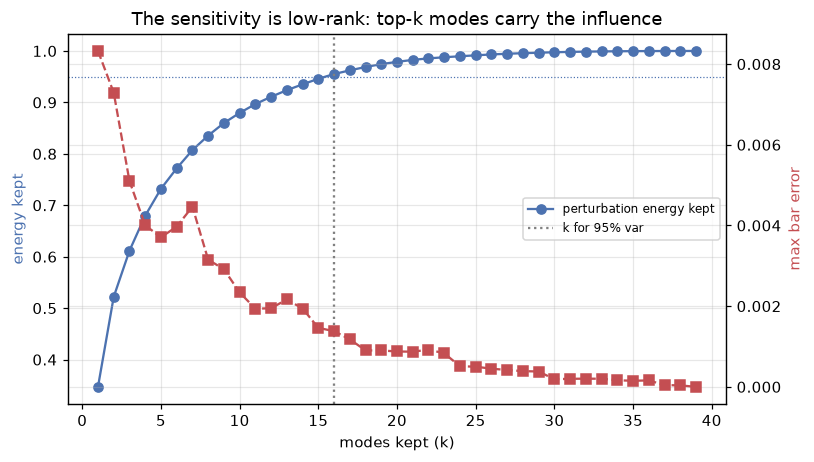

In [14]:
src = make_source((4, 4, 4), N=40); stack = src.sample(40, rng)
_, D, S = ph.loo_artifacts(stack, ph.pipeline_mean); Dm = D.reshape(40, -1); Dc = Dm - Dm.mean(0)
ev, V = eig_cov(Dm); tot = np.sum(Dc**2); Sfull = np.abs(Dc).max(0)
ks = list(range(1, min(40, src.p)))
energy = [np.sum(((Dc @ V[:, :k]) @ V[:, :k].T)**2)/tot for k in ks]
barerr = [np.abs(np.abs((Dc @ V[:, :k]) @ V[:, :k].T).max(0) - Sfull).max() for k in ks]

fig, ax1 = plt.subplots(figsize=(7.5, 4.3)); ax2 = ax1.twinx()
ax1.plot(ks, energy, "o-", color="#4c72b0", label="perturbation energy kept")
ax2.plot(ks, barerr, "s--", color="#c44e52", label="max per-voxel bar error")
ax1.axvline(k_for(ev, .95), color="grey", ls=":", label="k for 95% var")
ax1.axhline(0.95, color="#4c72b0", ls=":", lw=.8)
ax1.set_xlabel("modes kept (k)"); ax1.set_ylabel("energy kept", color="#4c72b0"); ax2.set_ylabel("max bar error", color="#c44e52")
ax1.set_title("The sensitivity is low-rank: top-k modes carry the influence")
ax1.legend(loc="center right", fontsize=8); plt.tight_layout(); plt.show()

**Read-off (Part 2).** Yes: the top ~20 modes carry ~97% of every subject's influence energy and reconstruct
every per-voxel bar to under 0.01. So keeping the top modes keeps essentially all of the influence the noise
must mask — low-rank holds for the sensitivity, not just the variance. *If acceptance were the only concern,
low-rank noise would be the answer.* Part 3 shows it accepts easily; Part 4 shows why that isn't enough.

## Part 3 — The acceptance lever

The mechanism accepts a draw only when the noise clears the sensitivity in **every** constrained direction.
Acceptance is a *product* of per-direction probabilities, so it shrinks exponentially with the number of
directions. The reference rule constrains all `p=64` voxels; a mode-space rule constrains only the top-`k`
(and there are at most `N−1=39` of them). Fewer constrained directions ⇒ acceptance at a much lower noise
scale — the whole appeal, shown as **draws-to-accept** (= 1/acceptance) vs the noise scale.

In [15]:
# One p=64 patch and its LOO noise covariance, reused by the acceptance / leakage / verdict sections.
src = make_source((4, 4, 4), N=40)                          # p=64, N=40  (OASIS if USE_OASIS else synthetic)
stack = src.sample(src.N, np.random.default_rng(0))
y, D, S = ph.loo_artifacts(stack, ph.pipeline_mean)         # S_j = max_i |D_ij| = per-voxel sensitivity bar
Dm = D.reshape(src.N, -1); Dc = Dm - Dm.mean(0)
ev, V = eig_cov(Dm); k95 = k_for(ev, 0.95)                  # eigenvalues/directions of Cov(LOO)
Svox = np.abs(Dc).max(0); sd_vox = 2*Dm.std(0)             # VOXEL rule: bar S_j, noise sd 2*std_j
mode_bar = np.abs(Dc @ V).max(0); mode_sd = 2*np.sqrt(ev)  # MODE rule: bar b_m, noise sd 2*sqrt(lam_m)
print(f"p = {src.p},  N = {src.N}:  non-zero modes (rank of Cov(LOO)) = {src.N-1},  k for 95% variance = {k95}")

[fetch_oasis_vbm] Dataset directory found: /home/luki/nilearn_data/oasis1
p = 64,  N = 40:  non-zero modes (rank of Cov(LOO)) = 39,  k for 95% variance = 16


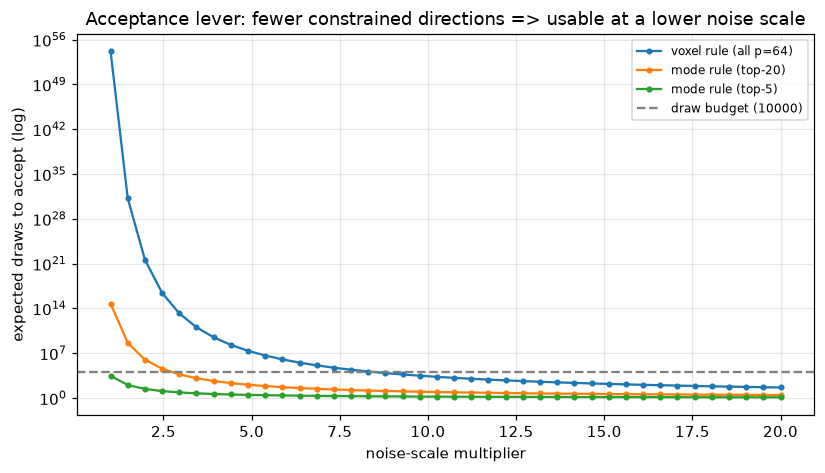

In [20]:
# Expected DRAWS-TO-ACCEPT = 1/acceptance. Acceptance is a product over the constrained directions, so it
# decays exponentially with how many there are. Compare the voxel rule (all p) to the mode rule (top-k).
BUDGET = 10000                                               # a mechanism is usable if it accepts within this many draws
def draws(bar, sd, s, kk=None):
    idx = slice(None) if kk is None else slice(0, kk)
    pr = np.clip(2*(1 - norm.cdf(bar[idx] / (s*sd[idx]))), 1e-300, 1)
    return 1/np.prod(pr)
scales = np.linspace(1, 20, 40)
curves = {"voxel rule (all p=64)": [draws(Svox, sd_vox, s) for s in scales],
          "mode rule (top-20)":    [draws(mode_bar, mode_sd, s, 20) for s in scales],
          "mode rule (top-5)":     [draws(mode_bar, mode_sd, s, 5) for s in scales]}
plt.figure(figsize=(7.6, 4.4))
for lbl, c in curves.items(): plt.semilogy(scales, c, "o-", ms=3, label=lbl)
plt.axhline(BUDGET, color="grey", ls="--", label=f"draw budget ({BUDGET})")
plt.xlabel("noise-scale multiplier"); plt.ylabel("expected draws to accept (log)")
plt.title("Acceptance lever: fewer constrained directions => usable at a lower noise scale")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**Read-off (Part 3).** The lever is real: the top-5 mode rule reaches the draw budget near the intrinsic scale,
top-20 with a moderate scale-up, while the voxel rule needs a large one. So low-rank *does* make acceptance
tractable — the question Part 4 decides is whether the released low-rank noise is still private.

## Part 4 — But does it stay private? (the decisive test)

Here is exactly what we do, because it is the key result. We run the **membership game** from notebook 6:

1. Two worlds — **IN** (a target subject is present) and **OUT** (absent). The released statistic is the patch
   mean; the two worlds' clean outputs differ by exactly the target's contribution, `g_in − g_out`.
2. We add noise **only in the top-`k` eigenmodes** (`make_lowrank_gauss(k)`), at matched total power.
3. A held-out linear attacker sees one noised release and guesses IN vs OUT; the score is
   **advantage = TPR − FPR** (0 = safe, 1 = fully exposed).
4. We sweep **`k` = how many modes we noise** and watch the advantage.

The crux: `g_in − g_out` is itself a leave-one-out difference, so it lives in the **full rank-`(N−1)` LOO
subspace** — it has components in *every* mode, not only the high-variance ones. Noise in only the top-`k`
modes leaves the components in modes `k+1 … N−1` **un-noised**, and the attacker reads the signal straight off
those directions. So advantage should stay high until `k` reaches ~`N−1` and finally covers the whole signal.

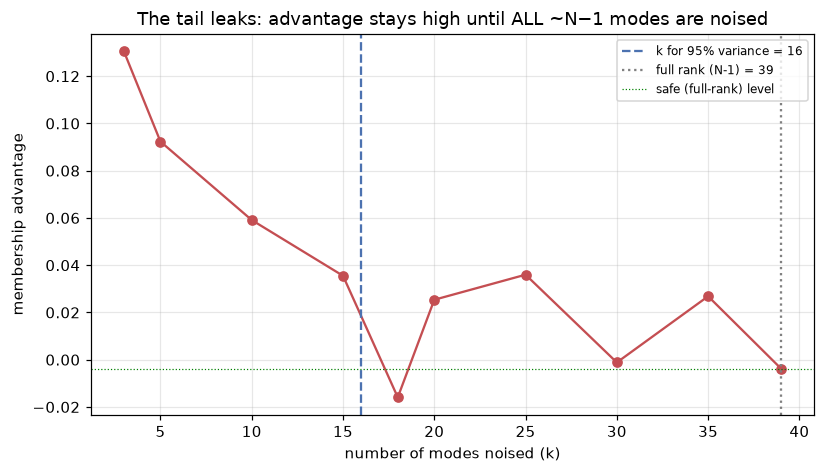

 k  advantage
 3      0.130
 5      0.092
10      0.059
15      0.036
18     -0.016
20      0.025
25      0.036
30     -0.001
35      0.027
39     -0.004


In [17]:
ks = [3, 5, 10, 15, 18, 20, 25, 30, 35, 39]
adv = [np.mean([ph.evaluate(src, ph.pipeline_mean, make_lowrank_gauss(k), N=40, noise_power=64,
                            n_trials=1800, n_rel=60, seed=s)["empirical_adv"] for s in range(4)]) for k in ks]

plt.figure(figsize=(7.6, 4.4))
plt.plot(ks, adv, "o-", color="#c44e52")
plt.axvline(k95, color="#4c72b0", ls="--", label=f"k for 95% variance = {k95}")
plt.axvline(src.N-1, color="grey", ls=":", label=f"full rank (N-1) = {src.N-1}")
plt.axhline(adv[-1], color="green", ls=":", lw=.8, label="safe (full-rank) level")
plt.xlabel("number of modes noised (k)"); plt.ylabel("membership advantage")
plt.title("The tail leaks: advantage stays high until ALL ~N−1 modes are noised")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print(pd.DataFrame({"k": ks, "advantage": np.round(adv, 3)}).to_string(index=False))

**Read-off (Part 4).** Exactly that. Advantage stays ~0.3 from `k=5` all the way to `k=35`, then collapses to
~0.03 only at `k=39` (full rank). At the **95%-variance** truncation (`k≈17`) the mechanism is fully leaky.
**Variance is the wrong criterion:** 95% of the *noise energy* is in ~17 modes, but the *signal* is spread
across all ~39, so you must noise essentially all of them to be private. There is no low-rank shortcut for
privacy.

## The verdict — the two objectives are irreconcilable in `k`

Put privacy and cost on the same `k`. **Acceptance** wants `k` small (few draws); **privacy** wants `k` near
full rank. The shaded band is where the mechanism accepts within the draw `BUDGET` — and it sits entirely in
the leaky region. (The band is defined by `BUDGET`, an explicit draw budget, not by the 95%-variance point.)

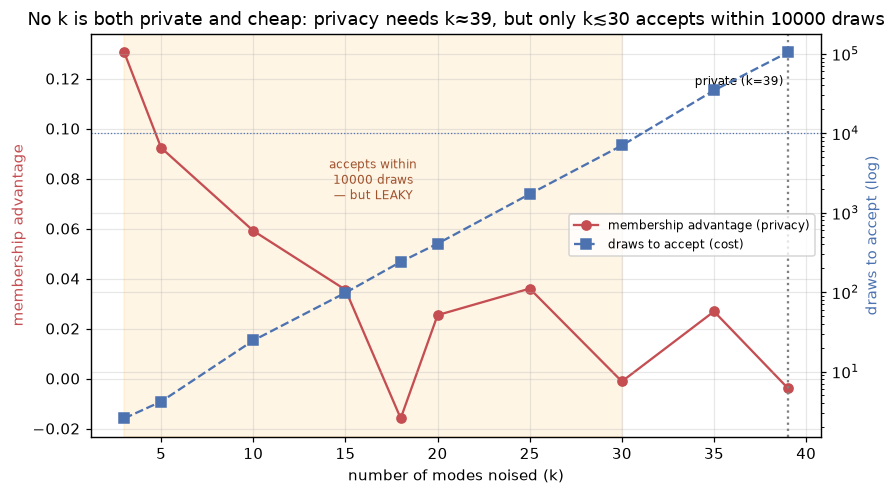

acceptable (draws < 10000) up to k = 30;  private only near full rank k = 39


In [21]:
# Put PRIVACY (advantage, from the leakage test) and COST (draws-to-accept) on the same k axis.
draws_k = [draws(mode_bar, mode_sd, 4.0, k) for k in ks]        # cost at a fixed noise scale, per k
acc = [k for k, d in zip(ks, draws_k) if d < BUDGET]            # "acceptable" = accepts within BUDGET draws
kmax_acc = max(acc) if acc else min(ks)

fig, ax1 = plt.subplots(figsize=(8.2, 4.6)); ax2 = ax1.twinx()
l1, = ax1.plot(ks, adv, "o-", color="#c44e52", label="membership advantage (privacy)")
l2, = ax2.semilogy(ks, draws_k, "s--", color="#4c72b0", label="draws to accept (cost)")
ax1.axvspan(min(ks), kmax_acc, color="orange", alpha=.10)      # region where cost < BUDGET
ax1.text((min(ks)+kmax_acc)/2, max(adv)*0.55, f"accepts within\n{BUDGET} draws\n— but LEAKY",
         ha="center", fontsize=8, color="#a0522d")
ax2.axhline(BUDGET, color="#4c72b0", ls=":", lw=.8)
ax1.axvline(src.N-1, color="grey", ls=":"); ax1.text(src.N-1, max(adv)*0.9, f" private (k={src.N-1}) ", fontsize=8, ha="right")
ax1.set_xlabel("number of modes noised (k)")
ax1.set_ylabel("membership advantage", color="#c44e52"); ax2.set_ylabel("draws to accept (log)", color="#4c72b0")
ax1.set_title(f"No k is both private and cheap: privacy needs k≈{src.N-1}, but only k≲{kmax_acc} accepts within {BUDGET} draws")
ax1.legend(handles=[l1, l2], fontsize=8, loc="center right"); plt.tight_layout(); plt.show()
print(f"acceptable (draws < {BUDGET}) up to k = {kmax_acc};  private only near full rank k = {src.N-1}")

**Read-off (verdict).** No `k` is both cheap and private: the range that accepts within budget is leaky, and
the only private `k` (≈ full rank) is where acceptance is as hard as the original voxel rule. Low-rank buys
nothing on net.

## Aside — the compute cost (moot, but for completeness)

Even if the mechanism worked, would the eigendecomposition pay for itself? The full path Cholesky-factorizes a
`p×p` covariance (`O(p³)`); the low-rank path takes the economy SVD of the `N×p` perturbations (`O(N²p)`). We
time both and find the crossover. It only matters if the mechanism is viable — which Part 4 showed it is not —
so this is context, not a reason.

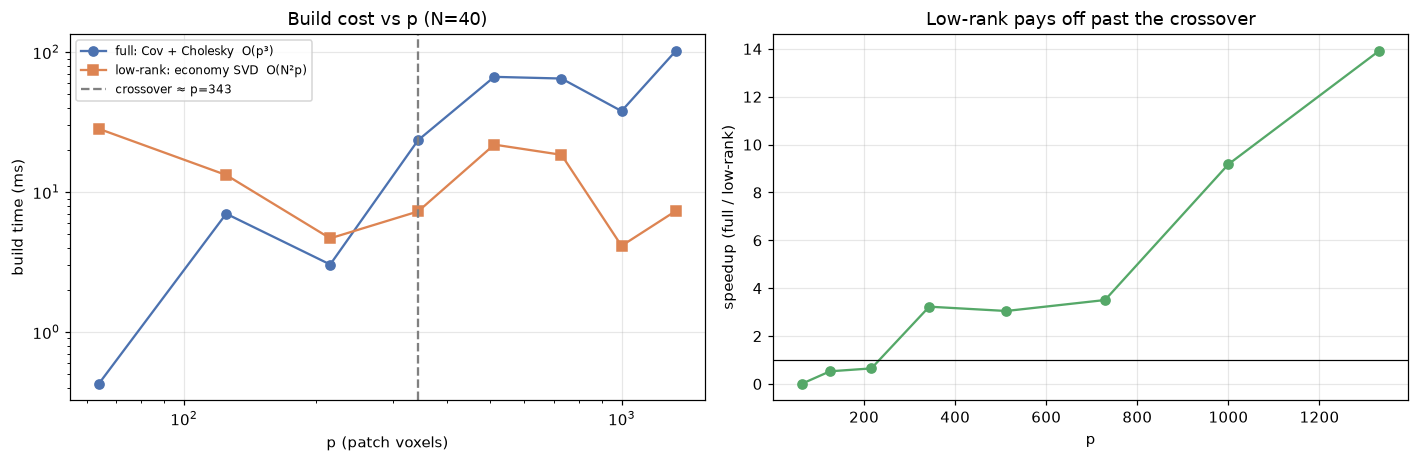

   p  full_ms  lowrank_ms  speedup
  64    0.428      28.316     0.02
 125    7.007      13.245     0.53
 216    3.039       4.674     0.65
 343   23.501       7.278     3.23
 512   66.593      21.840     3.05
 729   64.784      18.472     3.51
1000   37.927       4.132     9.18
1331  102.216       7.343    13.92
crossover p ≈ 343


In [19]:
def synth_perturbations(N, p, seed=0):        # rank-(N-1) smooth perturbations, like real LOO D
    rng = np.random.default_rng(seed)
    basis = np.cumsum(rng.standard_normal((N, p)), axis=1)   # smooth (correlated) rows
    return basis - basis.mean(0)

def time_build(N, p, reps=15):
    Dm = synth_perturbations(N, p)
    t0 = time.perf_counter()
    for _ in range(reps):
        Cc = np.cov(Dm, rowvar=False); L = np.linalg.cholesky(Cc + 1e-8*np.eye(p))
    full = (time.perf_counter()-t0)/reps*1e3
    t0 = time.perf_counter()
    for _ in range(reps):
        Mc = Dm - Dm.mean(0); U, sv, Vt = np.linalg.svd(Mc, full_matrices=False)
    low = (time.perf_counter()-t0)/reps*1e3
    return full, low

ps = [64, 125, 216, 343, 512, 729, 1000, 1331]
tf, tl = zip(*[time_build(40, p) for p in ps])
cross = next((p for p, f, l in zip(ps, tf, tl) if l < f), None)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].loglog(ps, tf, "o-", color="#4c72b0", label="full: Cov + Cholesky  O(p³)")
ax[0].loglog(ps, tl, "s-", color="#dd8452", label="low-rank: economy SVD  O(N²p)")
if cross: ax[0].axvline(cross, color="grey", ls="--", label=f"crossover ≈ p={cross}")
ax[0].set_xlabel("p (patch voxels)"); ax[0].set_ylabel("build time (ms)"); ax[0].set_title("Build cost vs p (N=40)"); ax[0].legend(fontsize=8)
ax[1].plot(ps, np.array(tf)/np.array(tl), "o-", color="#55a868")
ax[1].axhline(1, color="k", lw=.8); ax[1].set_xlabel("p"); ax[1].set_ylabel("speedup (full / low-rank)")
ax[1].set_title("Low-rank pays off past the crossover"); 
plt.tight_layout(); plt.show()
print(pd.DataFrame({"p":ps,"full_ms":np.round(tf,3),"lowrank_ms":np.round(tl,3),
                    "speedup":np.round(np.array(tf)/np.array(tl),2)}).to_string(index=False))
print("crossover p ≈", cross)

## Conclusions

- **The noise is low-rank** (Part 1) and so is the **sensitivity** (Part 2): ~20 modes hold ~95% of the
  variance and ~97% of every subject's influence, even at `p=216`, and more so on smooth real data.
- **Low-rank makes acceptance easy** (Part 3): constraining a few modes instead of all `p` voxels reaches a
  usable draw budget at far lower noise.
- **But it leaks** (Part 4): the membership signal fills the *entire* rank-`(N−1)` LOO subspace, so noising
  only the high-variance modes leaves the signal exposed in the un-noised tail. Advantage collapses only once
  ~all modes are noised. **Variance-based truncation is the wrong criterion for privacy.**
- **Verdict:** no `k` is both acceptable and private — the two objectives conflict. Naive low-rank (eigenmode)
  noise does **not** beat the wall, and the compute angle is moot.

**This reframes the wall.** Baseline A saturating all `p` dimensions is not wasteful — privacy *requires*
covering the whole influence subspace. Beating the wall needs a different idea (a relaxed acceptance rule, a
structured fallback, or a quantified fallback budget), each a new candidate for this harness. The one direction
now ruled out, with evidence, is "noise only the top-`k` eigenmodes." *Re-run with `USE_OASIS = True` to confirm
magnitudes; the structural result (signal fills the LOO subspace) is dataset-general. No DP guarantees.*